In [1]:
import spotipy
from spotipy.oauth2 import SpotifyOAuth
import pandas as pd
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import networkx as nx
import matplotlib.pyplot as plt
import math
import seaborn as sns

# Initialize the Spotify API client
sp = spotipy.Spotify(auth_manager=SpotifyOAuth(client_id="f6f6de34e09741d28b1766703ec2560a",
                                               client_secret="19cd0d5906204557934a27406a24e4ca",
                                               redirect_uri="http://localhost:8888/callback",
                                               scope="user-library-read playlist-modify-public playlist-read-private",
                                               requests_timeout=30))

In [2]:
comp = pd.read_csv(r'./data/kinesandbeyondfall2024/competitors.csv')
roun = pd.read_csv(r'./data/kinesandbeyondfall2024/rounds.csv')
subm = pd.read_csv(r'./data/kinesandbeyondfall2024/submissions.csv')
vote = pd.read_csv(r'./data/kinesandbeyondfall2024/votes.csv')

subb = subm[['Spotify URI','Submitter ID','Round ID']].rename(columns={'Submitter ID':'Voter ID'})
subb['Points Assigned'] = 7
vote = pd.concat([subb,vote])

vote = vote.merge(comp,left_on='Voter ID',right_on='ID').drop(columns='ID')
roun1 = roun[['ID','Name']].rename(columns={'ID':'Round ID','Name': 'Round'})

vote = vote.merge(roun1,on='Round ID')

votesum = vote.groupby(['Round ID','Name'])['Points Assigned'].agg('sum').reset_index()
votesum = votesum[votesum['Points Assigned']!=26].drop(columns='Points Assigned')

df_filtered = vote.merge(votesum, on=['Round ID', 'Name'], how='left', indicator=True)
vote = df_filtered[df_filtered['_merge'] == 'left_only'].drop(columns=['_merge'])



C:\Users\ajwin\AppData\Local\Temp\ipykernel_25016\4220195841.py:29: UserWarning: Glyph 127810 (\N{FALLEN LEAF}) missing from font(s) DejaVu Sans.
  plt.savefig('heatmap fall songs {}.png'.format(i))
C:\Users\ajwin\AppData\Local\Temp\ipykernel_25016\4220195841.py:29: UserWarning: Glyph 128378 (\N{MAN DANCING}) missing from font(s) DejaVu Sans.
  plt.savefig('heatmap fall songs {}.png'.format(i))
C:\Users\ajwin\AppData\Local\Temp\ipykernel_25016\4220195841.py:29: UserWarning: Glyph 127995 (\N{EMOJI MODIFIER FITZPATRICK TYPE-1-2}) missing from font(s) DejaVu Sans.
  plt.savefig('heatmap fall songs {}.png'.format(i))
C:\Users\ajwin\AppData\Local\Temp\ipykernel_25016\4220195841.py:29: UserWarning: Glyph 128579 (\N{UPSIDE-DOWN FACE}) missing from font(s) DejaVu Sans.
  plt.savefig('heatmap fall songs {}.png'.format(i))
C:\Users\ajwin\AppData\Local\Temp\ipykernel_25016\4220195841.py:29: UserWarning: Glyph 129309 (\N{HANDSHAKE}) missing from font(s) DejaVu Sans.
  plt.savefig('heatmap fall son

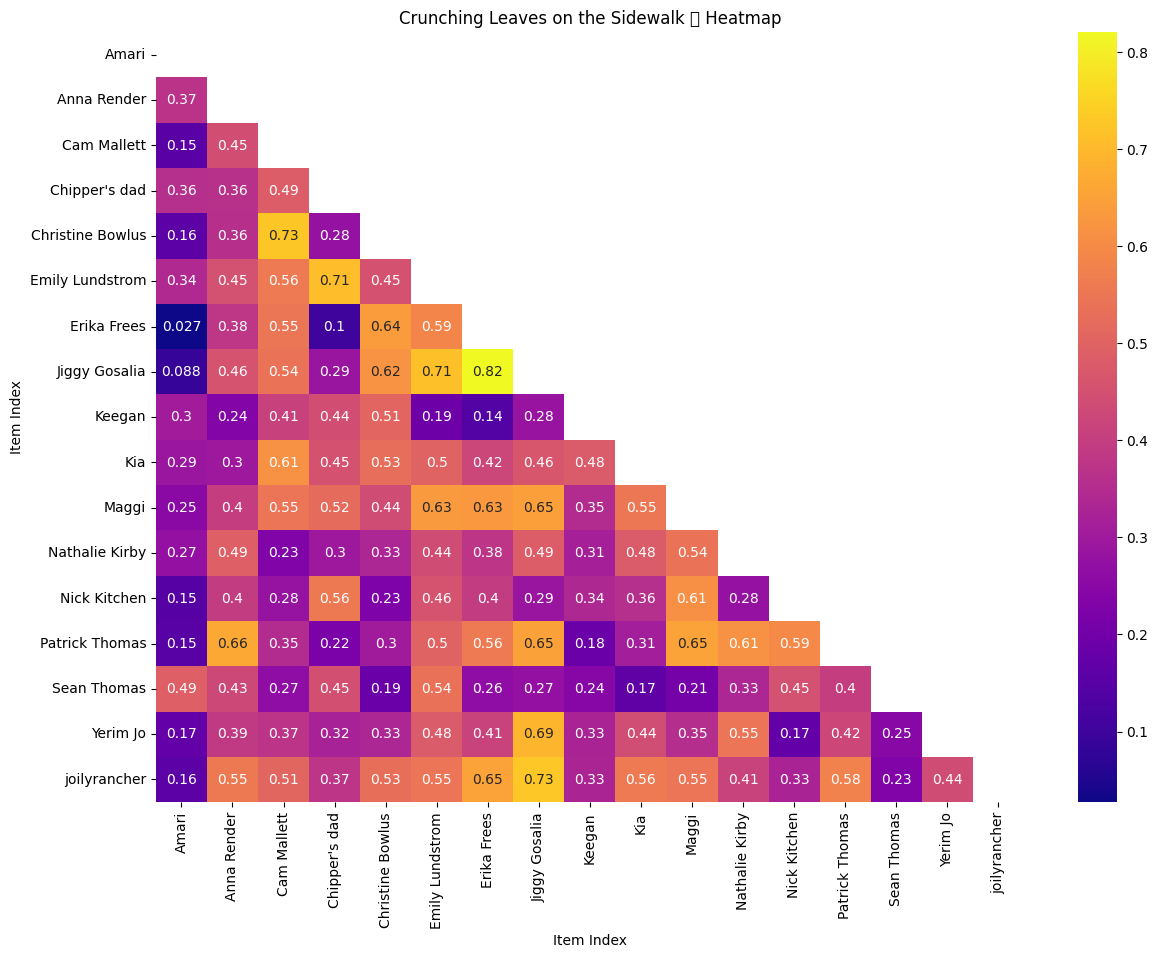

c:\Users\ajwin\Projects\SpotifyPlaylistBot\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128378 (\N{MAN DANCING}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\ajwin\Projects\SpotifyPlaylistBot\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127995 (\N{EMOJI MODIFIER FITZPATRICK TYPE-1-2}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


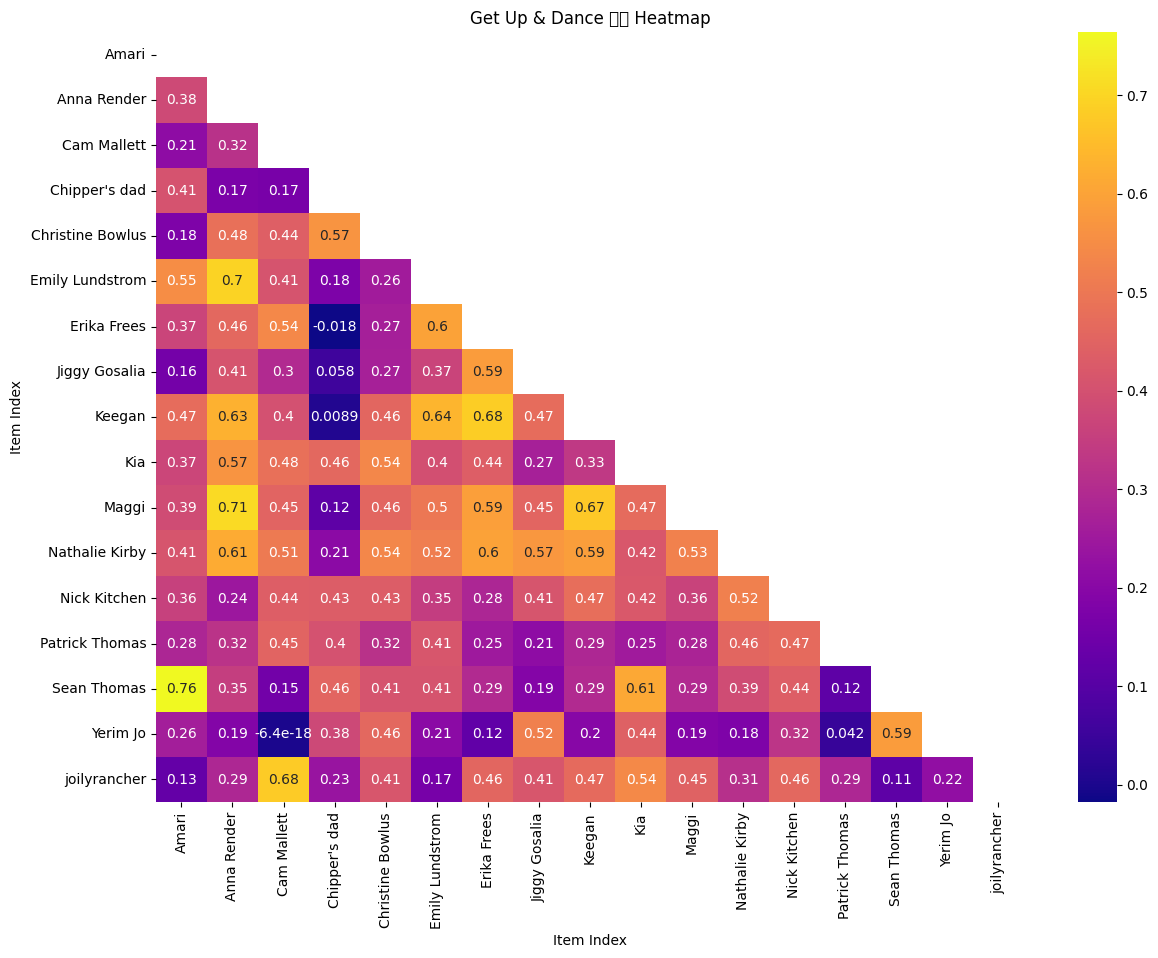

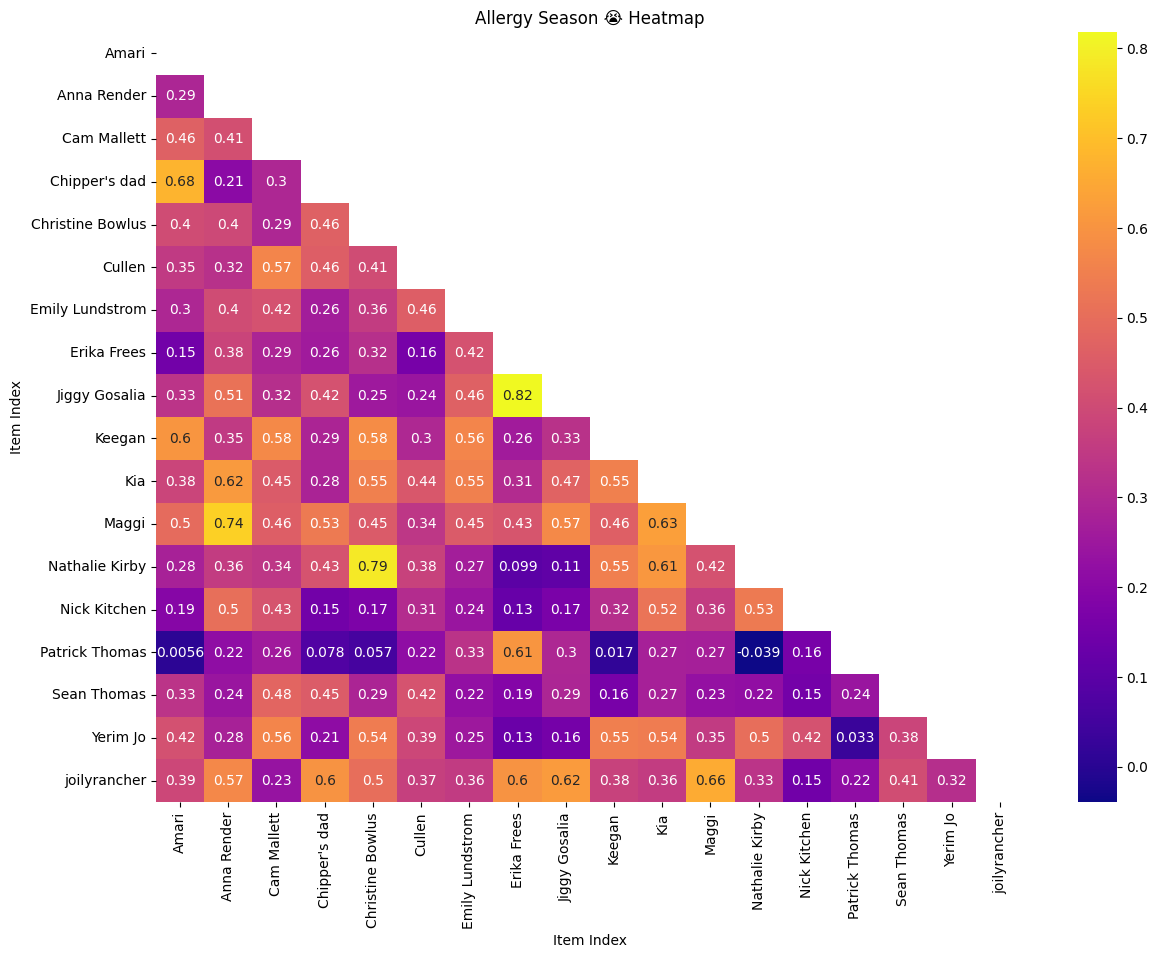

c:\Users\ajwin\Projects\SpotifyPlaylistBot\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128579 (\N{UPSIDE-DOWN FACE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


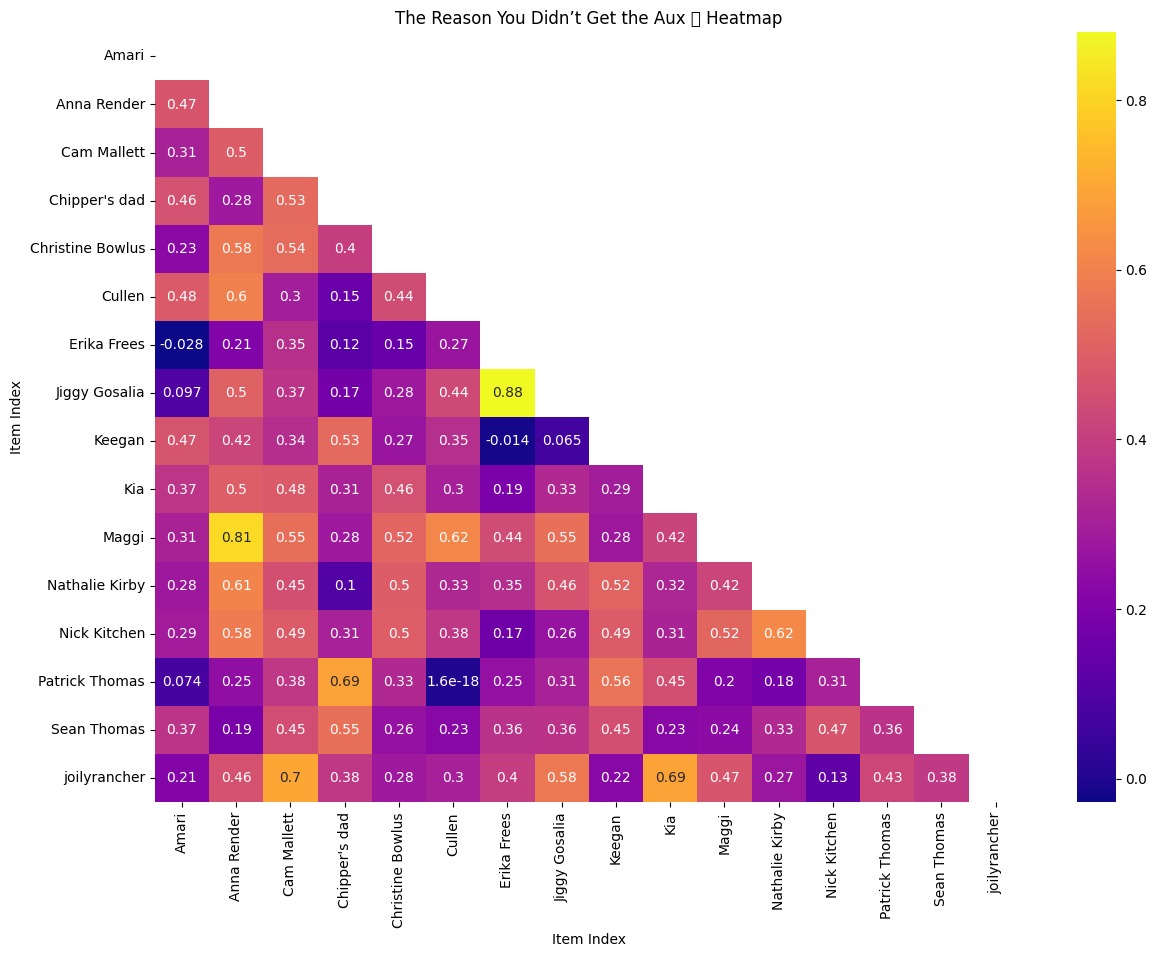

c:\Users\ajwin\Projects\SpotifyPlaylistBot\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129309 (\N{HANDSHAKE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


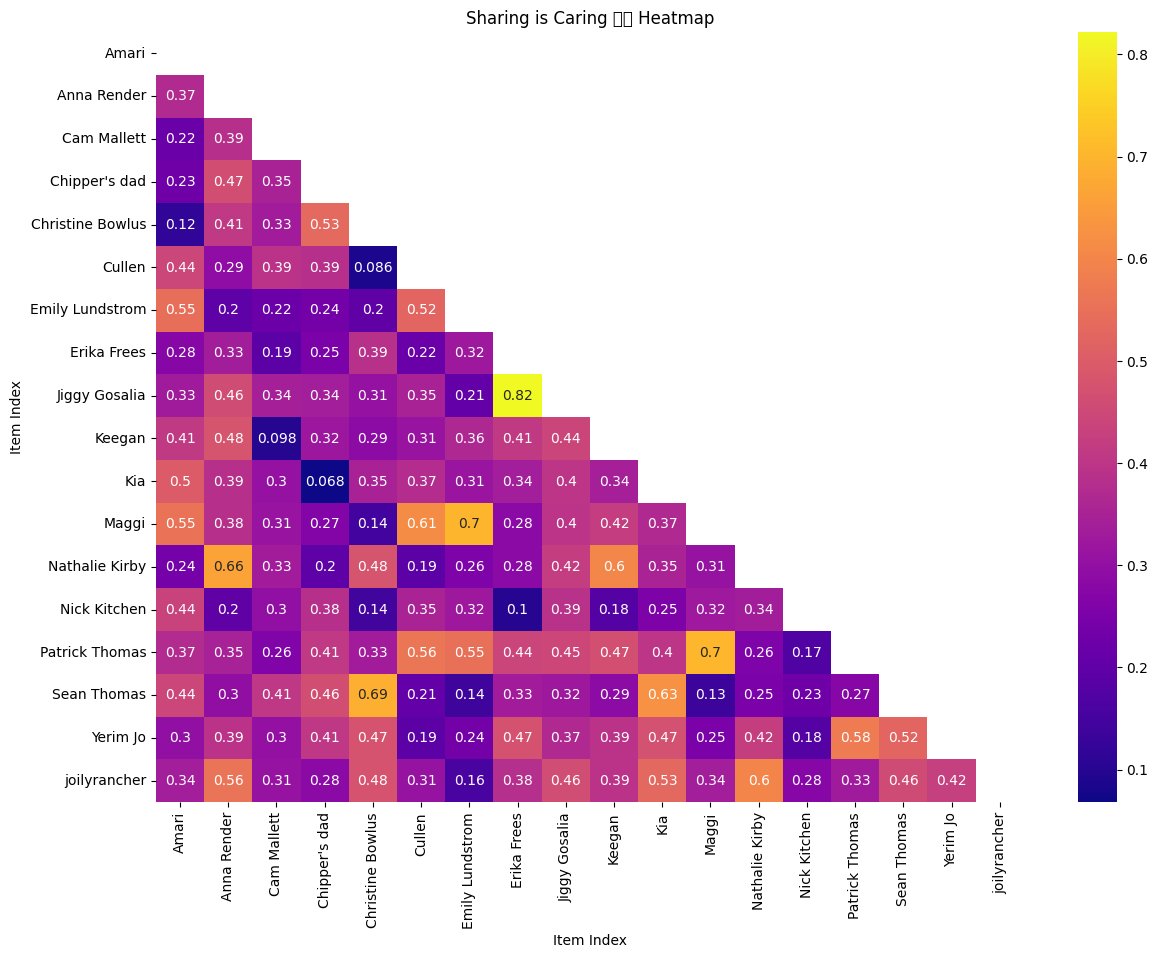

c:\Users\ajwin\Projects\SpotifyPlaylistBot\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128664 (\N{ONCOMING AUTOMOBILE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


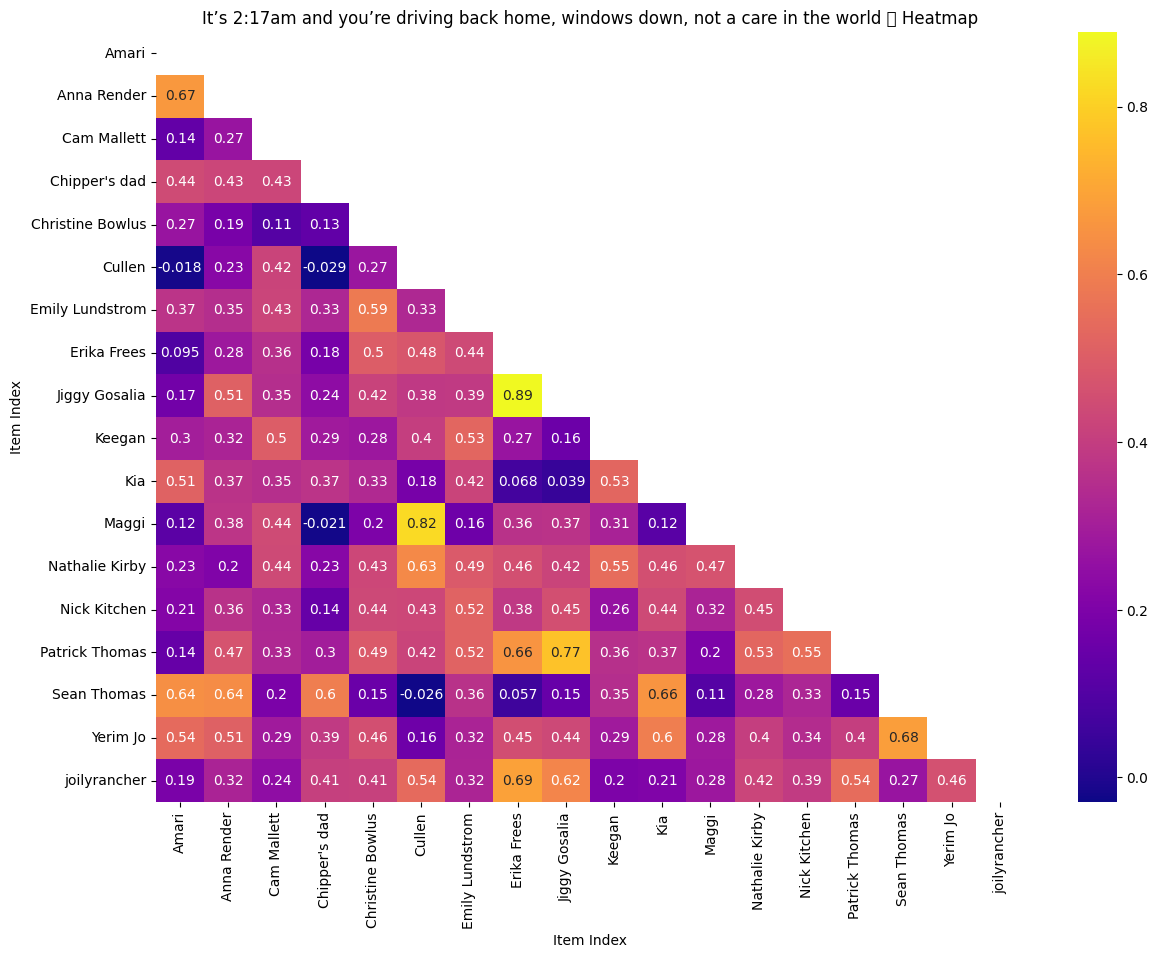

c:\Users\ajwin\Projects\SpotifyPlaylistBot\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128133 (\N{NAIL POLISH}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


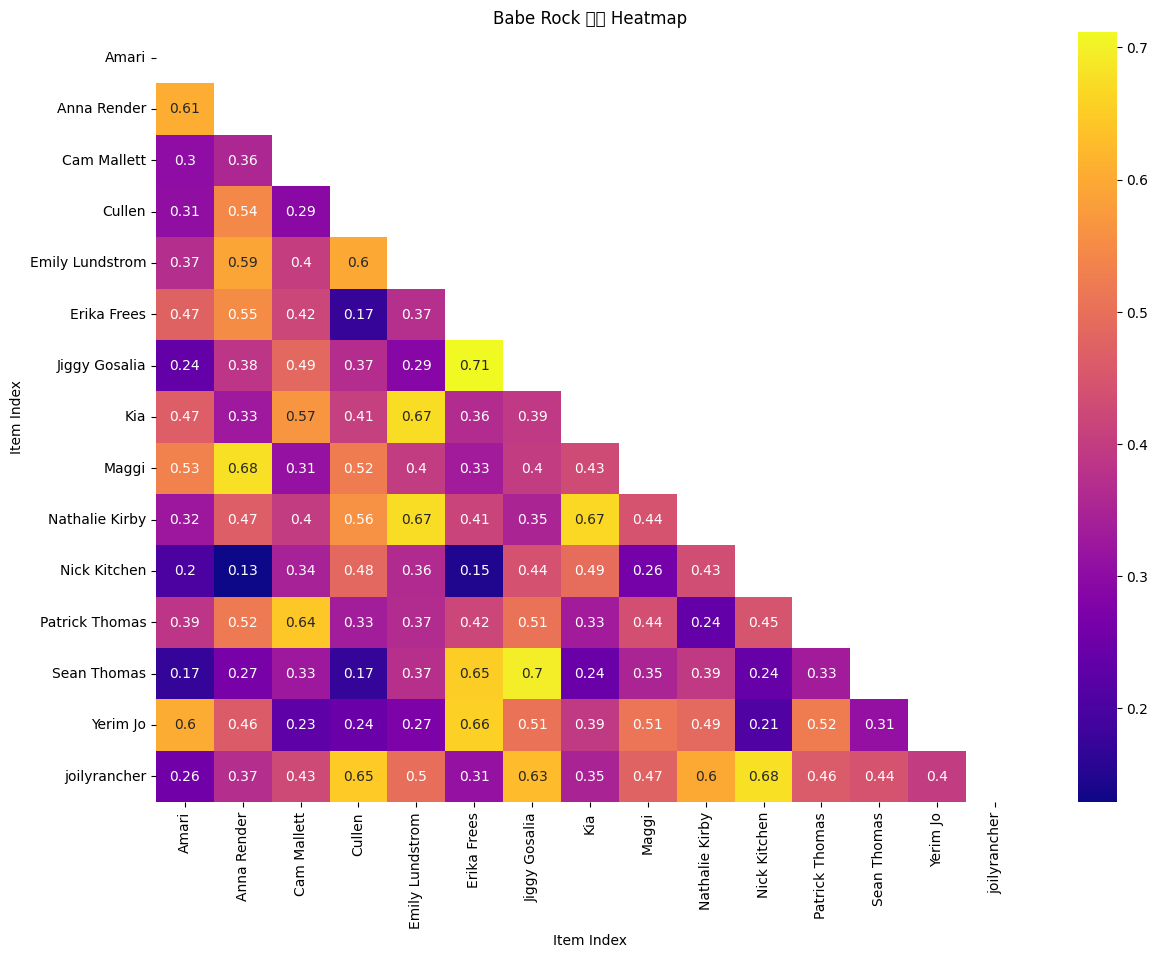

c:\Users\ajwin\Projects\SpotifyPlaylistBot\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129514 (\N{TEST TUBE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


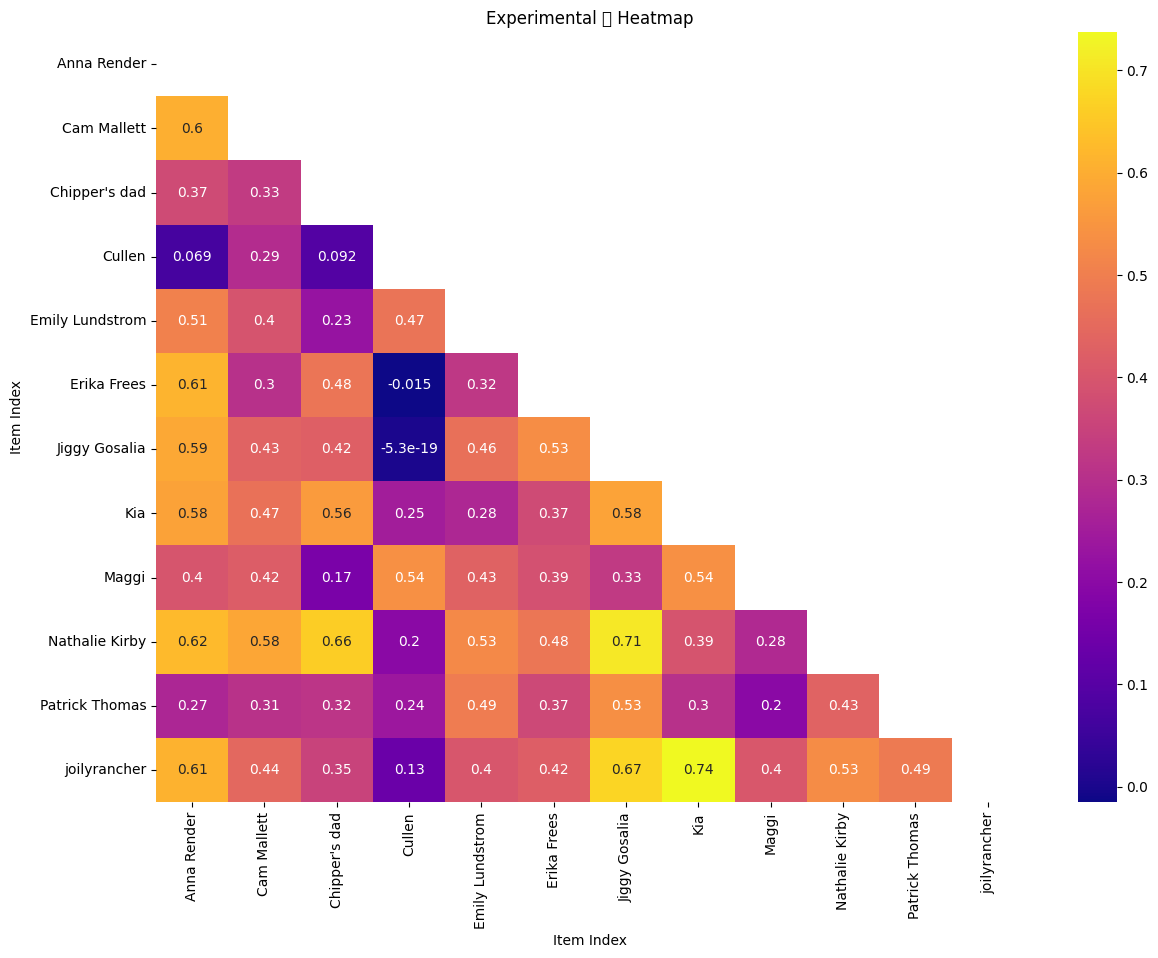

c:\Users\ajwin\Projects\SpotifyPlaylistBot\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129323 (\N{FACE WITH FINGER COVERING CLOSED LIPS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


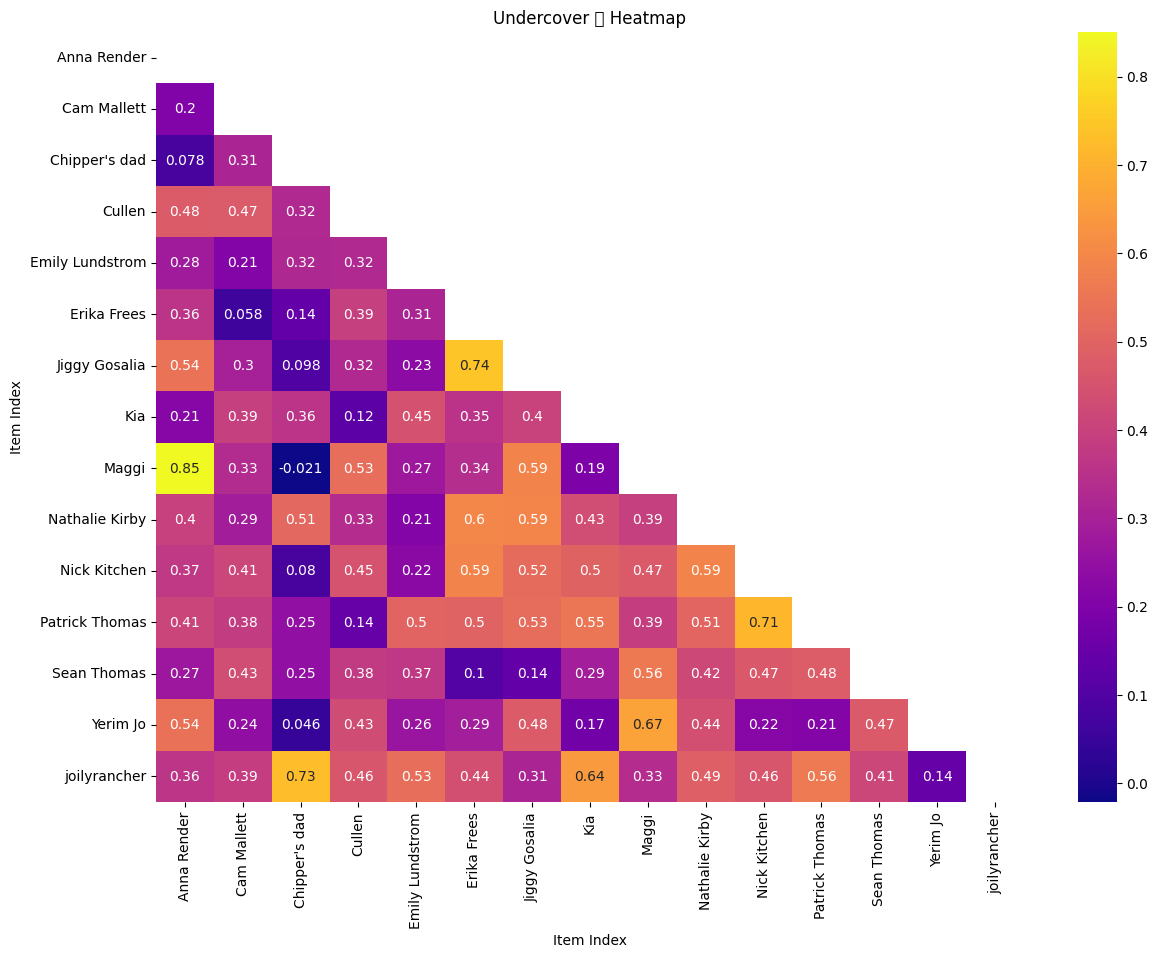

c:\Users\ajwin\Projects\SpotifyPlaylistBot\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10071 (\N{HEAVY EXCLAMATION MARK SYMBOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


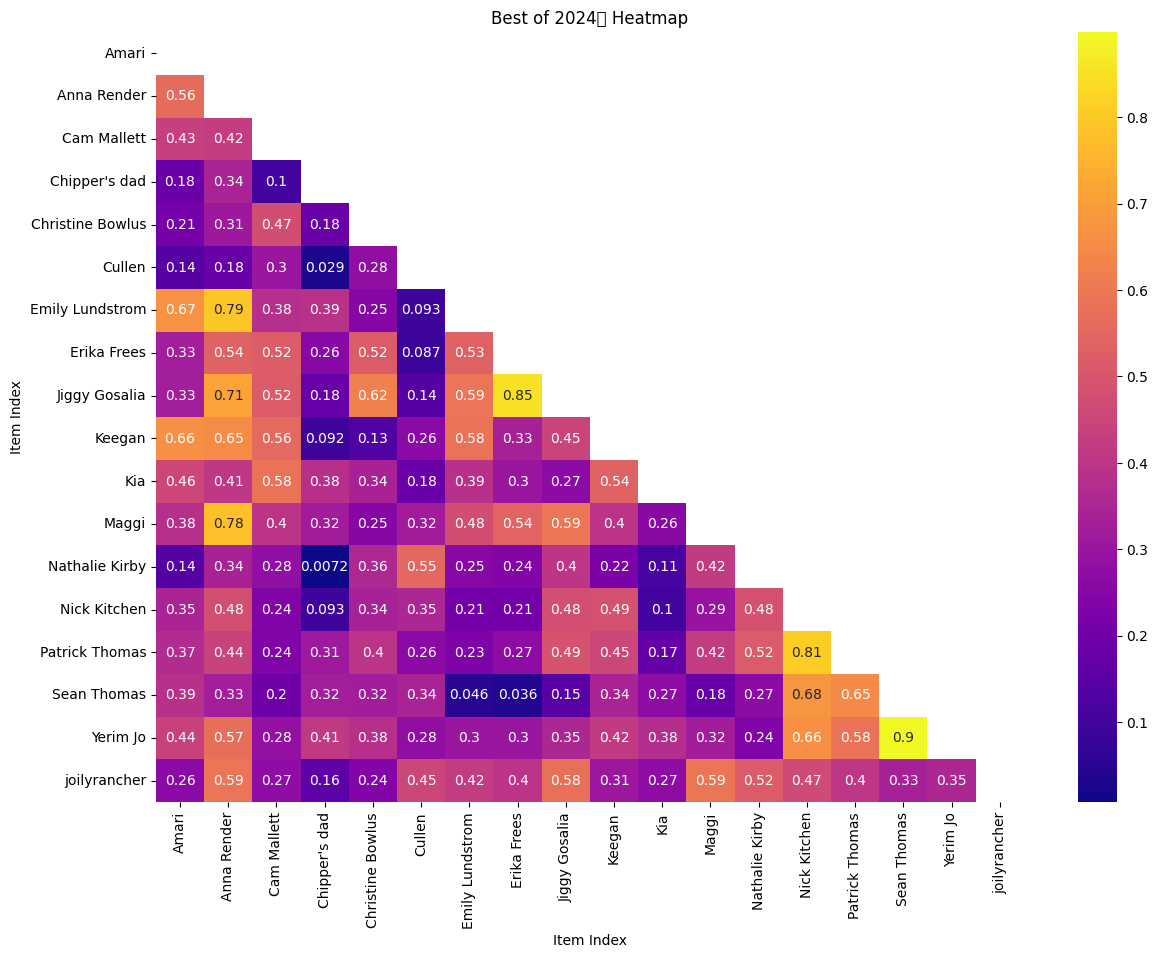

In [3]:
# Create a pivot table of Points Assigned by Voter ID and Song

for i in vote['Round'].unique():
    voter = vote[vote['Round'] == i]

    pivot = voter.pivot_table(
        index='Name', columns='Spotify URI', values='Points Assigned', fill_value=0
    )

    # Compute the similarity matrix (cosine similarity)
    similarity_matrix = cosine_similarity(pivot)
    #similarity_matrix = np.dot(pivot, pivot.T)

    # Convert the matrix to a DataFrame for easier manipulation
    similarity_df = pd.DataFrame(
        similarity_matrix, index=pivot.index, columns=pivot.index
    )
    mask = np.triu(np.ones_like(similarity_df, dtype=bool))

    similarity_df.to_csv('similarity_df.csv')

    plt.figure(figsize=(14, 10))
    sns.heatmap(similarity_df,mask=mask, annot=True, cmap="plasma", cbar=True)

    # Add labels
    plt.title("{} Heatmap".format(i))
    plt.xlabel("Item Index")
    plt.ylabel("Item Index")
    plt.savefig('heatmap fall songs {}.png'.format(i))
    # Show plot
    #plt.show()



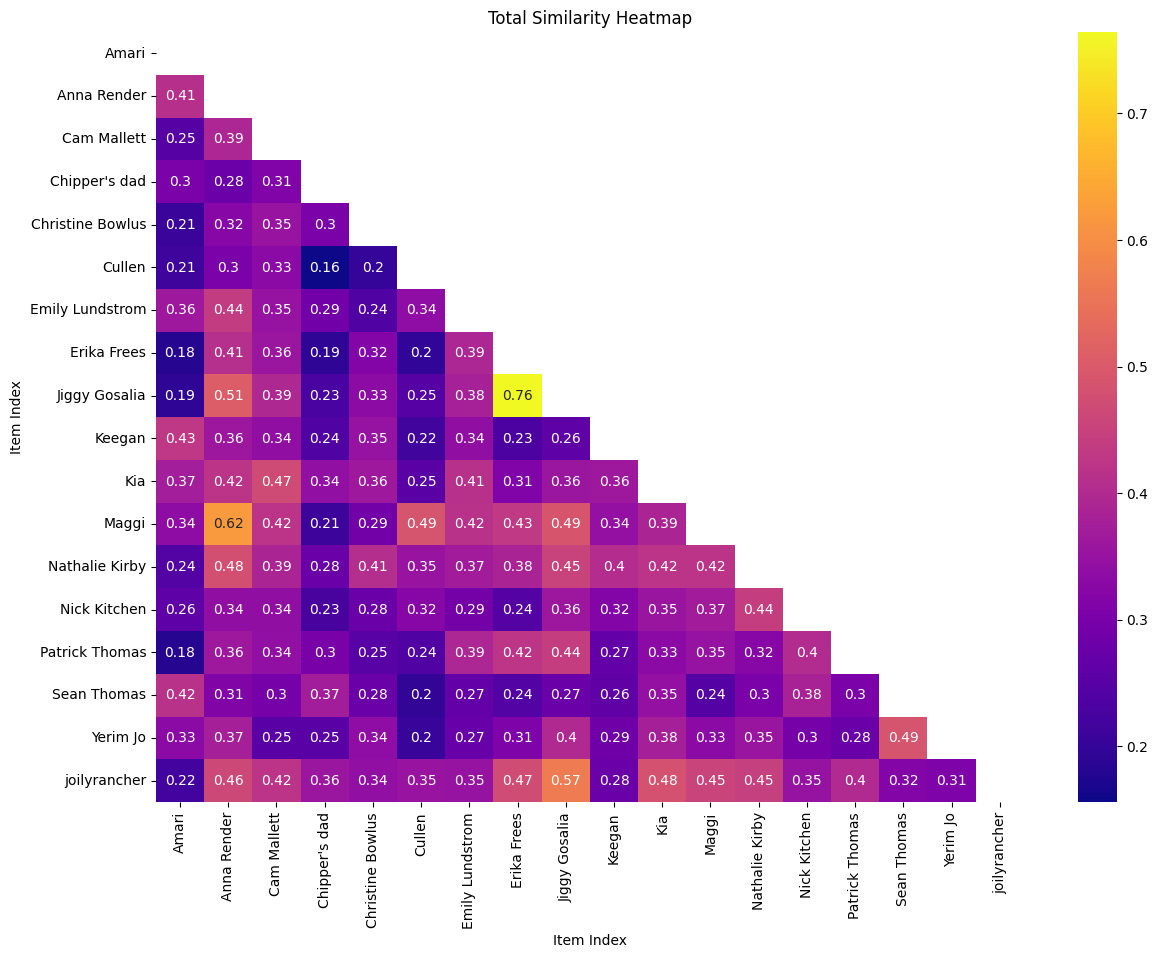

In [4]:

pivot = vote.pivot_table(
    index='Name', columns='Spotify URI', values='Points Assigned', fill_value=0
)

# Compute the similarity matrix (cosine similarity)
similarity_matrix = cosine_similarity(pivot)
#similarity_matrix = np.dot(pivot, pivot.T)

# Convert the matrix to a DataFrame for easier manipulation
similarity_df = pd.DataFrame(
    similarity_matrix, index=pivot.index, columns=pivot.index
)
mask = np.triu(np.ones_like(similarity_df, dtype=bool))

similarity_df.to_csv('similarity_df.csv')

plt.figure(figsize=(14, 10))
sns.heatmap(similarity_df,mask=mask, annot=True, cmap="plasma", cbar=True)

# Add labels
plt.title("{} Heatmap".format("Total Similarity"))
plt.xlabel("Item Index")
plt.ylabel("Item Index")
plt.savefig('heatmap fall songs {}.png'.format('Total Similarity'))
# Show plot
#plt.show()

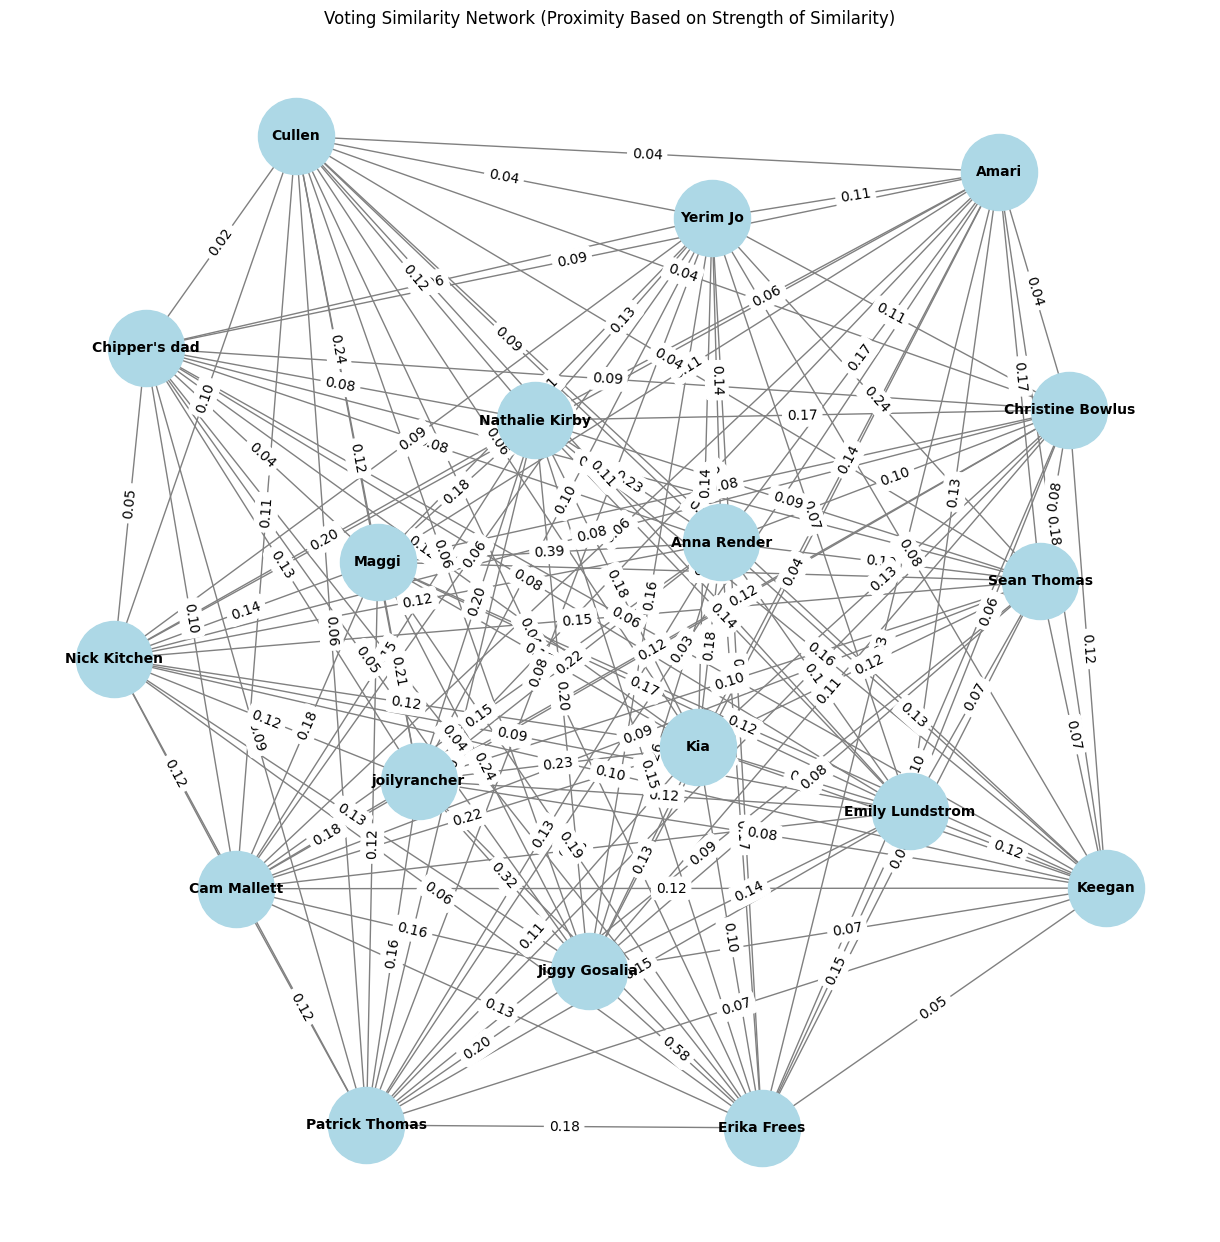

In [5]:

# Create a graph using NetworkX
G = nx.Graph()

# Add nodes (Voter IDs)
for voter in similarity_df.index:
    G.add_node(voter)

# Add weighted edges based on similarity
for i, voter1 in enumerate(similarity_df.index):
    for j, voter2 in enumerate(similarity_df.columns):
        if i != j:  # Exclude self-similarity
            weight = similarity_df.iloc[i, j]
            if weight > 0:  # Add an edge only if there’s some similarity
                G.add_edge(voter1, voter2, weight=weight**2)

# Use a force-directed layout (spring layout) where edge weights determine proximity
pos = nx.spring_layout(G, weight='weight', seed=42)

# Visualize the graph
plt.figure(figsize=(12, 12))
nx.draw(
    G, pos, with_labels=True, node_color='lightblue', edge_color='gray',
    node_size=3000, font_size=10, font_weight='bold'
)

# Add edge labels to show weights
edge_labels = nx.get_edge_attributes(G, 'weight')
edge_labels = {key: f"{value:.2f}" for key, value in edge_labels.items()}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

plt.title("Voting Similarity Network (Proximity Based on Strength of Similarity)")
plt.savefig('../output/network graph fall songs.png')
#plt.show()

In [24]:
value_counts = vote['Points Assigned'].value_counts().sort_index()


In [6]:
similarity_df.mean().sort_values()

Name
Cullen              0.311225
Chipper's dad       0.313111
Amari               0.327937
Christine Bowlus    0.342482
Keegan              0.349019
Sean Thomas         0.350104
Yerim Jo            0.358206
Nick Kitchen        0.364975
Patrick Thomas      0.365275
Erika Frees         0.381178
Emily Lundstrom     0.382556
Cam Mallett         0.388912
Kia                 0.408679
Nathalie Kirby      0.414335
joilyrancher        0.420860
Maggi               0.422287
Jiggy Gosalia       0.424241
Anna Render         0.432925
dtype: float64

In [143]:
pivot

Spotify URI,spotify:track:011plYoLTqmoFML8birgSA,spotify:track:01tA4XmJ4fGQNwti6b2hPm,spotify:track:07XaOyTS5hyaWiUK1Bc3bR,spotify:track:0APt4t1Dab58sYmGQ4jgij,spotify:track:0COqiPhxzoWICwFCS4eZcp,spotify:track:0H1OyEooZ5SzBYYdJEzxoy,spotify:track:0KKkJNfGyhkQ5aFogxQAPU,spotify:track:0M2ASyWJhjvc4AzneR7sG6,spotify:track:0O45fw2L5vsWpdsOdXwNAR,spotify:track:0ZNU020wNYvgW84iljPkPP,...,spotify:track:7bY6SzSnuhUTj6Ei4HgEP9,spotify:track:7brQHA2CgQpcMBiOlfiXYb,spotify:track:7gYwIAHB6VxzLJFSZMMv8i,spotify:track:7kEmejohe2N5hiGhbXlErp,spotify:track:7oof6K1s09QXjOxDucR2r8,spotify:track:7p02T2V97WFFSOf7mV3ZZH,spotify:track:7pMJ455NDmDtnAxSRniJt2,spotify:track:7pu8AhGUxHZSCWTkQ2eb5M,spotify:track:7vLdUdtQinRrLEZdmocQLS,spotify:track:7y8X0Z04gJCKtfrnSAMywJ
Name,,,,,,,,,,,,,,,,,,,,,
Amari,0.0,5.0,0.0,1.0,0.0,7.0,4.0,0.0,3.0,2.0,...,0.0,1.0,2.0,1.0,0.0,1.0,0.0,3.0,0.0,-1.0
Anna Render,1.0,0.0,1.0,0.0,2.0,2.0,7.0,0.0,2.0,0.0,...,0.0,-1.0,0.0,3.0,0.0,0.0,0.0,3.0,5.0,-1.0
Cam Mallett,2.0,-1.0,2.0,2.0,1.0,0.0,1.0,0.0,1.0,2.0,...,2.0,2.0,0.0,2.0,2.0,7.0,5.0,2.0,0.0,1.0
Chipper's dad,6.0,2.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,2.0,0.0,7.0,7.0,0.0,3.0,0.0,1.0,-1.0
Christine Bowlus,0.0,1.0,0.0,7.0,0.0,2.0,0.0,0.0,-1.0,3.0,...,3.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,-1.0
Cullen,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,...,3.0,7.0,0.0,2.0,0.0,0.0,0.0,0.0,1.0,0.0
Emily Lundstrom,3.0,-1.0,2.0,1.0,5.0,2.0,1.0,0.0,7.0,0.0,...,7.0,2.0,2.0,0.0,2.0,0.0,0.0,2.0,1.0,0.0
Erika Frees,0.0,0.0,7.0,2.0,1.0,0.0,0.0,0.0,3.0,0.0,...,1.0,0.0,0.0,0.0,1.0,1.0,1.0,7.0,5.0,7.0
Jiggy Gosalia,4.0,0.0,3.0,2.0,1.0,0.0,2.0,-1.0,1.0,0.0,...,0.0,1.0,0.0,2.0,0.0,1.0,1.0,2.0,4.0,5.0


,Spotify URI,Voter ID,Round ID,Points Assigned,Created,Comment,Name
0,spotify:track:0APt4t1Dab58sYmGQ4jgij,39da05e8e1a9459faaa6d5f2bedda107,fd310df6d55c4a3d9062c53c89faf125,7,NaN,NaN,NaN
1,spotify:track:0d2iYfpKoM0QCKvcLCkBao,61b8afbd4eba45bc8ce638cdffe643b9,fd310df6d55c4a3d9062c53c89faf125,7,NaN,NaN,NaN
2,spotify:track:0ZNU020wNYvgW84iljPkPP,800249571ade4a4a9be6f732597b2b1b,fd310df6d55c4a3d9062c53c89faf125,7,NaN,NaN,NaN
3,spotify:track:1uaGSDFsLdReQgg8p7Obwh,ee6e12f87bed491fb09e44be019d3e9b,fd310df6d55c4a3d9062c53c89faf125,7,NaN,NaN,NaN
4,spotify:track:20uknEOwx3PpiGL2Es2vCg,3402fb74cd344129b61d9919865d352a,fd310df6d55c4a3d9062c53c89faf125,7,NaN,NaN,NaN
...,...,...,...,...,...,...,...
1640,spotify:track:7oof6K1s09QXjOxDucR2r8,a8108758e11b4fa69f914a9976ed4714,11978e86f8a34577b39128b295337b5b,2,2024-12-04T03:54:36Z,NaN,Nick Kitchen
1641,spotify:track:30y5OpD8TPAru2wsyZDD4S,3dd1dd1369444476adfbd33696985d21,11978e86f8a34577b39128b295337b5b,7,2024-12-04T04:58:09Z,Hell yes,Chipper's dad
1642,spotify:track:4H8vbXQIbHgu5AHzm3QxT6,3dd1dd1369444476adfbd33696985d21,11978e86f8a34577b39128b295337b5b,-1,2024-12-04T04:58:09Z,NaN,Chipper's dad
1643,spotify:track:5sn1BmEOPP1bu4cZq9OgoF,3dd1dd1369444476adfbd33696985d21,11978e86f8a34577b39128b295337b5b,6,2024-12-04T04:58:09Z,NaN,Chipper's dad


In [16]:
# # Get current user's profile data
# user_profile = sp.user() #user id can be found in profile of the desktop app
# # Extract profile picture URL
# images = user_profile.get('images', [])
# if images:
#     profile_image_url = images[0]['url']
#     print(f"Profile Image URL: {profile_image_url}")
# else:
#     print("No profile image found.")

In [47]:
vote

,Spotify URI,Voter ID,Created,Points Assigned,Comment,Round ID,Name
0,spotify:track:0ZNU020wNYvgW84iljPkPP,ee6e12f87bed491fb09e44be019d3e9b,2024-10-05T15:40:28Z,1,NaN,fd310df6d55c4a3d9062c53c89faf125,joilyrancher
1,spotify:track:20uknEOwx3PpiGL2Es2vCg,ee6e12f87bed491fb09e44be019d3e9b,2024-10-05T15:40:28Z,1,NaN,fd310df6d55c4a3d9062c53c89faf125,joilyrancher
2,spotify:track:2nmvn13bmL5cMfO9oW34KW,ee6e12f87bed491fb09e44be019d3e9b,2024-10-05T15:40:28Z,1,NaN,fd310df6d55c4a3d9062c53c89faf125,joilyrancher
3,spotify:track:2QjOHCTQ1Jl3zawyYOpxh6,ee6e12f87bed491fb09e44be019d3e9b,2024-10-05T15:40:28Z,1,NaN,fd310df6d55c4a3d9062c53c89faf125,joilyrancher
4,spotify:track:3CAX47TnPqTujLIQTw8nwI,ee6e12f87bed491fb09e44be019d3e9b,2024-10-05T15:40:28Z,1,NaN,fd310df6d55c4a3d9062c53c89faf125,joilyrancher
...,...,...,...,...,...,...,...
1640,spotify:track:7oof6K1s09QXjOxDucR2r8,a8108758e11b4fa69f914a9976ed4714,2024-12-04T03:54:36Z,2,NaN,11978e86f8a34577b39128b295337b5b,Nick Kitchen
1641,spotify:track:30y5OpD8TPAru2wsyZDD4S,3dd1dd1369444476adfbd33696985d21,2024-12-04T04:58:09Z,7,Hell yes,11978e86f8a34577b39128b295337b5b,Chipper's dad
1642,spotify:track:4H8vbXQIbHgu5AHzm3QxT6,3dd1dd1369444476adfbd33696985d21,2024-12-04T04:58:09Z,-1,NaN,11978e86f8a34577b39128b295337b5b,Chipper's dad
1643,spotify:track:5sn1BmEOPP1bu4cZq9OgoF,3dd1dd1369444476adfbd33696985d21,2024-12-04T04:58:09Z,6,NaN,11978e86f8a34577b39128b295337b5b,Chipper's dad
